# TF-IDF с нуля

Ноутбук к теме [`lesson.md`](lesson.md). Считаем TF-IDF собственным кодом, сверяем с scikit-learn и проверяем на данных всё, что утверждает лекция.

1. Реализация и сверка с scikit-learn
2. Ранжирование и вопрос про «bird» три раза
3. Сколько повторов нужно, чтобы выйти на первое место
4. Потолок мешка слов
5. Связывание весов: сколько параметров это экономит

In [1]:
import matplotlib.pyplot as plt
import numpy as np

C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG, "axes.edgecolor": C_GRAY,
    "text.color": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

DOCS = [
    "the early bird gets the worm",
    "an early duck loves the worm",
    "i love my duck and my cat",
    "the worm wakes early",
    "a bird in my garden",
]
QUERY = "the early bird gets the worm"

## 1. Реализация и сверка с scikit-learn

«TF-IDF» — семейство формул, а не одна. Реализуем оба ходовых варианта IDF и убедимся, что наш код совпадает с библиотечным до машинной точности — иначе всем последующим числам грош цена.

In [2]:
def build_vocab(docs):
    return sorted({w for d in docs for w in d.split()})

def counts_of(doc, vocab):
    words = doc.split()
    return np.array([words.count(t) for t in vocab], dtype=float)

def idf_textbook(docs, vocab):
    """log(N / df) — учебная формула, обнуляет вездесущие термины."""
    n = len(docs)
    df = np.array([sum(1 for d in docs if t in d.split()) for t in vocab], dtype=float)
    return np.log(n / np.maximum(df, 1e-12))

def idf_sklearn(docs, vocab):
    """ln((1+N)/(1+df)) + 1 — сглаженный вариант scikit-learn."""
    n = len(docs)
    df = np.array([sum(1 for d in docs if t in d.split()) for t in vocab], dtype=float)
    return np.log((1 + n) / (1 + df)) + 1.0

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else 0.0

vocab = build_vocab(DOCS)
print(f"словарь: {len(vocab)} терминов")

t_idf, s_idf = idf_textbook(DOCS, vocab), idf_sklearn(DOCS, vocab)
print(f"\n{'термин':>8} {'df':>3} {'учебник':>9} {'sklearn':>9}")
for t, a, b in sorted(zip(vocab, t_idf, s_idf), key=lambda r: r[1]):
    df = sum(1 for d in DOCS if t in d.split())
    print(f"{t:>8} {df:>3} {a:>9.3f} {b:>9.3f}")

словарь: 17 терминов

  термин  df   учебник   sklearn
   early   3     0.511     1.405
     the   3     0.511     1.405
    worm   3     0.511     1.405
    bird   2     0.916     1.693
    duck   2     0.916     1.693
      my   2     0.916     1.693
       a   1     1.609     2.099
      an   1     1.609     2.099
     and   1     1.609     2.099
     cat   1     1.609     2.099
  garden   1     1.609     2.099
    gets   1     1.609     2.099
       i   1     1.609     2.099
      in   1     1.609     2.099
    love   1     1.609     2.099
   loves   1     1.609     2.099
   wakes   1     1.609     2.099


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(vocabulary={t: i for i, t in enumerate(vocab)},
                      token_pattern=r"(?u)\b\w+\b")
vec.fit(DOCS)

# sklearn: сырые счётчики × сглаженный IDF, затем L2-нормировка вектора
mine = []
for d in DOCS:
    v = counts_of(d, vocab) * s_idf
    n = np.linalg.norm(v)
    mine.append(v / n if n else v)
mine = np.array(mine)

print(f"max|IDF − sklearn.idf_|      = {np.abs(s_idf - vec.idf_).max():.2e}")
print(f"max|вектор − sklearn.matrix| = {np.abs(mine - vec.transform(DOCS).toarray()).max():.2e}")

max|IDF − sklearn.idf_|      = 0.00e+00
max|вектор − sklearn.matrix| = 1.11e-16


Совпадение точное. Дальше считаем по учебной формуле — она нагляднее, потому что честно обнуляет термины, встречающиеся во всех документах.

## 2. Ранжирование и вопрос про «bird» три раза

Основной вопрос из формулировки: как изменится позиция D5, если «bird» будет упомянут трижды.

In [4]:
def rank(docs, query, tf_scheme="linear", k1=1.5, b=0.75):
    """Косинусное ранжирование. tf_scheme: linear | sublinear | bm25."""
    vocab = build_vocab(docs + [query])
    idf = idf_textbook(docs, vocab)
    avgdl = np.mean([len(d.split()) for d in docs])

    def tf(doc):
        c = counts_of(doc, vocab)
        if tf_scheme == "sublinear":
            return np.where(c > 0, 1 + np.log(np.maximum(c, 1)), 0.0)
        if tf_scheme == "bm25":
            dl = len(doc.split())
            return c * (k1 + 1) / (c + k1 * (1 - b + b * dl / avgdl))
        return c / max(len(doc.split()), 1)

    q = tf(query) * idf
    return np.array([cosine(q, tf(d) * idf) for d in docs])

def show(sims, label):
    order = np.argsort(sims)[::-1]
    line = "   ".join(f"D{i + 1}={sims[i]:.3f}" for i in order)
    pos = int(np.where(order == 4)[0][0]) + 1
    print(f"{label:>28}: {line}   | D5 на {pos}-м месте")
    return pos

before = rank(DOCS, QUERY)
boosted = list(DOCS)
boosted[4] = "a bird bird bird in my garden"
after = rank(boosted, QUERY)

p1 = show(before, "исходный корпус")
p2 = show(after, "«bird» трижды")
print(f"\nранг D5: {p1} → {p2},  сходство {before[4]:.3f} → {after[4]:.3f}")

             исходный корпус: D1=1.000   D4=0.254   D2=0.179   D5=0.122   D3=0.000   | D5 на 4-м месте
               «bird» трижды: D1=1.000   D5=0.280   D4=0.254   D2=0.179   D3=0.000   | D5 на 2-м месте

ранг D5: 4 → 2,  сходство 0.122 → 0.280


Ранг вырос. Но важная оговорка: **рост сходства не гарантирует роста ранга** — он меняется, только если прирост перекрыл разрыв с соседом. Возьмём корпус, где впереди сразу три сильных документа.

In [5]:
wide_gap = [
    "the early bird gets the worm at dawn",
    "the early bird gets the worm again",
    "the early bird gets the worm today",
    "the worm wakes early",
    "a bird in my garden",
]
b1 = rank(wide_gap, QUERY)
wg = list(wide_gap)
wg[4] = "a bird bird bird in my garden"
b2 = rank(wg, QUERY)

q1 = show(b1, "три сильных конкурента: до")
q2 = show(b2, "три сильных конкурента: после")
print(f"\nсходство выросло {b1[4]:.3f} → {b2[4]:.3f}, а ранг остался {q1} → {q2}")

  три сильных конкурента: до: D3=0.436   D2=0.436   D1=0.324   D4=0.154   D5=0.020   | D5 на 5-м месте
три сильных конкурента: после: D3=0.436   D2=0.436   D1=0.324   D4=0.154   D5=0.058   | D5 на 5-м месте

сходство выросло 0.020 → 0.058, а ранг остался 5 → 5


## 3. Где накрутка упирается в потолок, а где проходит

Насыщение TF ограничивает рост веса одного термина. Но косинус нормирует длину вектора, и у накрутки одного слова есть **аналитический потолок**: документ, состоящий из одних «bird», имеет фиксированное направление, и ближе к запросу он уже не станет. Посчитаем этот потолок и проверим его прогоном.

In [6]:
# корпус, где лидер близок к запросу, но не дословен — обойти его в принципе можно
COMPETITIVE = [
    "the early bird gets the worm at dawn",
    "an early duck loves the worm",
    "i love my duck and my cat",
    "the worm wakes early",
    "a bird in my garden",
]
base = rank(COMPETITIVE, QUERY)

# потолок: направление документа из одних «bird»
v = build_vocab(COMPETITIVE + [QUERY])
idf = idf_textbook(COMPETITIVE, v)
q_vec = counts_of(QUERY, v) / len(QUERY.split()) * idf
pure_bird = np.zeros_like(q_vec)
pure_bird[v.index("bird")] = idf[v.index("bird")]
ceiling = cosine(q_vec, pure_bird)

print(f"сходство лидера D1:                 {base[0]:.3f}")
print(f"потолок документа из одних «bird»:  {ceiling:.3f}\n")
print(f"{'повторов «bird»':>16} {'сходство D5':>13}")
for k in (1, 3, 10, 50, 300):
    d = list(COMPETITIVE)
    d[4] = "a " + " ".join(["bird"] * k) + " in my garden"
    print(f"{k:>16} {rank(d, QUERY)[4]:>13.3f}")

сходство лидера D1:                 0.701
потолок документа из одних «bird»:  0.410

 повторов «bird»   сходство D5
               1         0.122
               3         0.280
              10         0.390
              50         0.409
             300         0.410


Сходство сходится к потолку и дальше не растёт — сколько бы раз слово ни повторили. Причина не в схеме TF, а в косинусе: документ из одного слова имеет фиксированное направление, а у запроса терминов пять.

Значит, содержательная атака — не на величину, а на **направление**: надо скопировать не одно слово, а весь запрос.

In [7]:
print(f"{'схема TF':>12} {'повторов фразы до 1-го места':>30}")
for scheme in ("linear", "sublinear", "bm25"):
    need = None
    for k in range(1, 101):
        d = list(COMPETITIVE)
        d[4] = "a garden note " + " ".join([QUERY] * k)
        if int(np.argmax(rank(d, QUERY, tf_scheme=scheme))) == 4:
            need = k
            break
    print(f"{scheme:>12} {str(need):>30}")

    схема TF   повторов фразы до 1-го места
      linear                              2
   sublinear                              2
        bm25                              2


Копирование запроса выводит документ на первое место за два повтора — и **схема TF на это не влияет**, потому что она меняет длину вектора, а не его направление.

Отсюда точная формулировка: насыщение TF ограничивает, сколько веса способен набрать один термин (рост при накрутке с 1 до 10 упоминаний падает с ×10 до ×2.17), но от копирования запроса целиком оно не защищает. Это работа не функции взвешивания, а антиспама поверх неё.

## 4. Потолок мешка слов

TF-IDF сравнивает строки, а не смыслы. Четыре пары, где это видно в чистом виде.

In [8]:
pairs = [
    ("автомобиль сломался", "машина неисправна", "синонимы, разные слова"),
    ("кошка спит на диване", "кот дремлет на софе", "полный перефраз"),
    ("мать любит дочь", "дочь любит мать", "порядок решает смысл"),
    ("фильм совсем не плохой", "фильм совсем не хороший", "противоположный смысл"),
]
corpus = [p for a, b, _ in pairs for p in (a, b)]
v2 = build_vocab(corpus)
idf2 = idf_textbook(corpus, v2)

print(f"{'случай':>24} {'сходство':>9}   пара")
for a, b, tag in pairs:
    s = cosine(counts_of(a, v2) * idf2, counts_of(b, v2) * idf2)
    print(f"{tag:>24} {s:>9.3f}   «{a}» ↔ «{b}»")

                  случай  сходство   пара
  синонимы, разные слова     0.000   «автомобиль сломался» ↔ «машина неисправна»
         полный перефраз     0.129   «кошка спит на диване» ↔ «кот дремлет на софе»
    порядок решает смысл     1.000   «мать любит дочь» ↔ «дочь любит мать»
   противоположный смысл     0.571   «фильм совсем не плохой» ↔ «фильм совсем не хороший»


Первая строка — рассогласование словаря: смысл один, общих слов ноль, сходство ноль. Третья и четвёртая — обратная беда: разный смысл при почти идентичном мешке. Ни одну из них нельзя починить внутри мешка слов, отсюда и переход к плотным представлениям.

## 5. Связывание весов: сколько параметров это экономит

Матрица эмбеддингов и матрица перед softmax имеют одинаковый размер $|V| \times d$. Связывание оставляет одну вместо двух — посчитаем долю в реальных конфигурациях.

In [9]:
configs = [
    ("небольшая LM", 30_000, 512, 6, 8),
    ("BERT-base", 30_522, 768, 12, 12),
    ("модель с большим словарём", 250_000, 1024, 24, 24),
]

def transformer_params(d, layers):
    """Грубая оценка блока: 4d² внимания + 8d² FFN на слой."""
    return layers * (4 * d * d + 8 * d * d)

print(f"{'конфигурация':>26} {'|V|':>8} {'d':>5} {'эмбеддинг':>11} {'тело':>9} {'экономия':>10}")
for name, V, d, layers, _heads in configs:
    emb = V * d
    body = transformer_params(d, layers)
    share = emb / (emb * 2 + body)
    print(f"{name:>26} {V:>8,} {d:>5} {emb / 1e6:>9.1f}M {body / 1e6:>7.1f}M {share:>9.1%}")

              конфигурация      |V|     d   эмбеддинг      тело   экономия
              небольшая LM   30,000   512      15.4M    18.9M     31.0%
                 BERT-base   30,522   768      23.4M    84.9M     17.8%
 модель с большим словарём  250,000  1024     256.0M   302.0M     31.5%


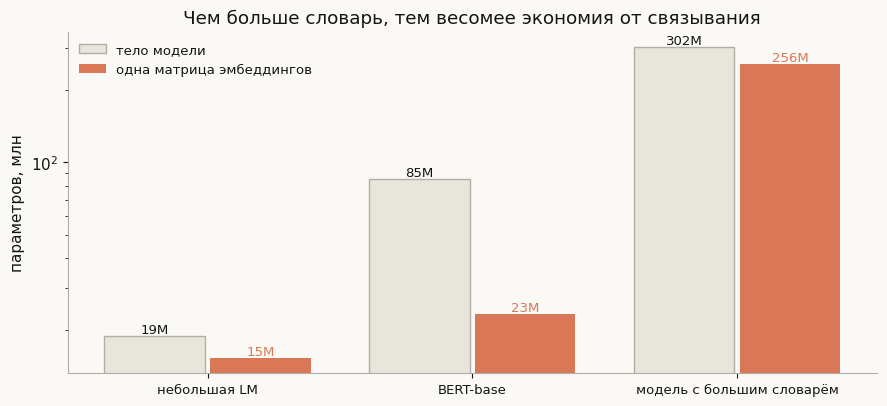

In [10]:
names = [c[0] for c in configs]
emb = np.array([c[1] * c[2] for c in configs]) / 1e6
body = np.array([transformer_params(c[2], c[3]) for c in configs]) / 1e6

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(configs))
ax.bar(x - 0.2, body, width=0.38, color=C_PANEL, edgecolor=C_GRAY, label="тело модели")
ax.bar(x + 0.2, emb, width=0.38, color=C_ORANGE, label="одна матрица эмбеддингов")
for i, (bd, em) in enumerate(zip(body, emb)):
    ax.text(i - 0.2, bd * 1.03, f"{bd:.0f}M", ha="center", fontsize=9.5)
    ax.text(i + 0.2, em * 1.03, f"{em:.0f}M", ha="center", fontsize=9.5, color=C_ORANGE)
ax.set_xticks(x, names, fontsize=9.5)
ax.set_ylabel("параметров, млн")
ax.set_yscale("log")
ax.set_title("Чем больше словарь, тем весомее экономия от связывания")
ax.legend(loc="upper left", fontsize=9.5)
despine(ax)
fig.tight_layout()

При большом словаре матрица эмбеддингов сопоставима с телом модели, и отказ от её дубликата экономит заметную долю всех весов. Но экономия — лишь одна из трёх причин: не менее важны согласованность представления слова на входе и выходе и дополнительная регуляризация редких слов, получающих градиент из двух источников.